# Pandas and 3D Data

Pandas support 2D data frame where as Numpy support 3D data structure as shown below. In the following example we create a 10 by 10 pixel image, with RGB channel.

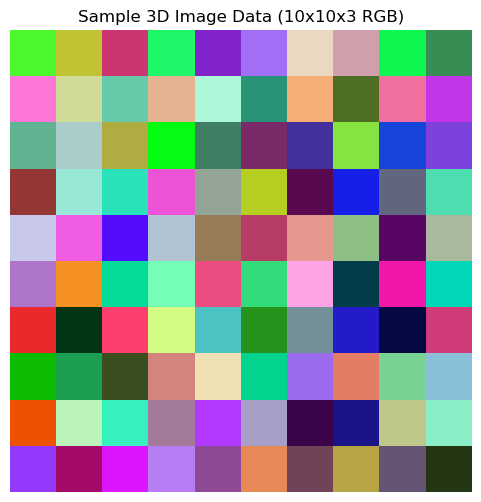

In [11]:
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

# Generate a sample image array (3D: height x width x channels)
image_3d = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_3d)
plt.title("Sample 3D Image Data (10x10x3 RGB)")
plt.axis('off')
plt.show()

In [12]:
# display the shape and dimensions of the image data as numPy array
print("\nImage shape:", image_3d.shape)
print("Image dimensions:", image_3d.ndim)


Image shape: (10, 10, 3)
Image dimensions: 3


In [13]:
# If we print the entire image data, it will show the pixel values for with a 10, 10, 3 array. the inner arrays is a 10 by 3 array.
print(image_3d)

[[[ 76 249  45]
  [192 196  51]
  [203  52 112]
  [ 31 246 104]
  [128  36 202]
  [160 111 245]
  [234 216 193]
  [209 158 172]
  [ 15 246  81]
  [ 55 141  84]]

 [[252 119 214]
  [208 219 152]
  [103 201 170]
  [230 179 144]
  [174 248 217]
  [ 39 147 119]
  [245 175 118]
  [ 78 110  36]
  [240 113 161]
  [194  54 232]]

 [[ 95 179 145]
  [170 205 203]
  [177 172  66]
  [  4 251  18]
  [ 62 127 101]
  [123  42 105]
  [ 67  49 155]
  [134 227  65]
  [ 23  68 219]
  [124  66 219]]

 [[146  55  51]
  [151 232 214]
  [ 42 226 186]
  [236  83 215]
  [148 165 150]
  [182 206  31]
  [ 90   9  78]
  [ 22  31 232]
  [ 97 101 126]
  [ 77 221 177]]

 [[200 200 235]
  [239  94 226]
  [ 83  12 253]
  [177 196 211]
  [152 124  86]
  [183  60 102]
  [230 151 142]
  [142 191 132]
  [ 87   7  99]
  [168 185 157]]

 [[174 116 199]
  [245 145  35]
  [  3 219 152]
  [117 254 182]
  [234  77 129]
  [ 52 219 123]
  [255 162 230]
  [  3  60  73]
  [241  23 171]
  [  0 214 184]]

 [[234  41  45]
  [  1  53  

How Numpy structure 3D data

```text
Image
 ├── Row 0
 │     ├── Column 0 pixel -> [R,G,B]
 │     ├── Column 1 pixel -> [R,G,B]
 │     └── ...
 │
 ├── Row 1
 │     ├── Column 0 pixel
 │     └── ...
```

In [14]:
print(image_3d.shape)
print(image_3d[0, 0])      # one pixel
print(image_3d[:, :, 0])   # red channel
print(image_3d[:, :, 1])   # green channel
print(image_3d[:, :, 2])   # blue channel

(10, 10, 3)
[ 76 249  45]
[[ 76 192 203  31 128 160 234 209  15  55]
 [252 208 103 230 174  39 245  78 240 194]
 [ 95 170 177   4  62 123  67 134  23 124]
 [146 151  42 236 148 182  90  22  97  77]
 [200 239  83 177 152 183 230 142  87 168]
 [174 245   3 117 234  52 255   3 241   0]
 [234   1 254 212  77  37 115  35   5 210]
 [ 11  27  58 211 239   2 154 228 120 137]
 [237 188  52 163 178 166  60  25 189 140]
 [146 165 219 183 143 231 113 182 101  35]]
[[249 196  52 246  36 111 216 158 246 141]
 [119 219 201 179 248 147 175 110 113  54]
 [179 205 172 251 127  42  49 227  68  66]
 [ 55 232 226  83 165 206   9  31 101 221]
 [200  94  12 196 124  60 151 191   7 185]
 [116 145 219 254  77 219 162  60  23 214]
 [ 41  53  62 251 196 146 144  26   9  59]
 [188 159  78 133 224 211 107 124 210 192]
 [ 82 243 241 122  57 160   4  20 200 238]
 [ 57  10  21 123  74 137  66 165  83  55]]
[[ 45  51 112 104 202 245 193 172  81  84]
 [214 152 170 144 217 119 118  36 161 232]
 [145 203  66  18 101 105 

In [15]:
# Convert to DataFrame for analysis
image_flat = image_3d.reshape(-1, 3)
image_df = pd.DataFrame(image_flat, columns=['R', 'G', 'B'])
print("Image data as DataFrame:")
print(image_df)

Image data as DataFrame:
      R    G    B
0    76  249   45
1   192  196   51
2   203   52  112
3    31  246  104
4   128   36  202
..  ...  ...  ...
95  231  137   87
96  113   66   88
97  182  165   66
98  101   83  116
99   35   55   20

[100 rows x 3 columns]


In [16]:
# display the shape and dimensions of the image data from image_df
print("\nDataFrame shape:", image_df.shape)
print("DataFrame dimensions:", image_df.ndim)


DataFrame shape: (100, 3)
DataFrame dimensions: 2


NumPy stores the image with a true 3D shape: height × width × color channels. When we reshape that array and load it into a DataFrame, each row becomes one pixel and each column becomes one color channel, so Pandas represents the data as a 2D table.

A DataFrame is fundamentally 2-dimensional:

- rows
- columns

The third dimension in this case is encoded inside the values for each row, rather than in the DataFrame’s axes.

## Multi-Index in Pandas

Pandas can mimic higher-dimensional structure using MultiIndex, but the underlying object is still a 2D DataFrame.

The following is an exmaple on how we convert a normal spreadsheet data in csv into a panel format.

In [17]:
# Read csv file with pandas
raw_df = pd.read_csv("sales.csv")
raw_df

,Store,Quarter,Sales_2024,Sales_2025,Profit_2024,Profit_2025,Expenses_2024,Expenses_2025
0,Store A,Q1,67,184,158,52,194,145
1,Store A,Q2,93,132,149,66,111,104
2,Store A,Q3,65,158,150,114,116,81
3,Store A,Q4,188,58,123,149,109,189
4,Store B,Q1,167,90,63,108,147,171
5,Store B,Q2,50,73,176,132,156,127
6,Store B,Q3,85,135,75,93,115,85
7,Store B,Q4,73,143,173,70,53,93
8,Store C,Q1,160,66,94,64,179,175
9,Store C,Q2,142,152,158,189,175,82


### Why Convert from Wide Form to Long Form?

Converting data from wide form to long form is essential for:

1. **Analysis Flexibility**: Long-form data is easier to filter, group, and aggregate, especially when working with libraries like Pandas.
2. **Visualization**: Many plotting libraries, such as Seaborn and Plotly, expect data in long form for creating advanced visualizations.
3. **Compatibility**: Long-form data aligns with the "tidy data" principles, making it compatible with a wide range of data analysis tools.

In the next cell, we demonstrate how to reshape the panel data for specific analysis tasks.

https://towardsdatascience.com/reshaping-a-pandas-dataframe-long-to-wide-and-vice-versa-517c7f0995ad/

https://pandas.pydata.org/docs/reference/api/pandas.wide_to_long.html

In [18]:
# Load CSV
raw_df = pd.read_csv("sales.csv")

# Convert wide format to panel (long) format
panel_df = pd.wide_to_long(
    raw_df,
    stubnames=['Sales', 'Profit', 'Expenses'],
    i=['Store', 'Quarter'],
    j='Year',
    sep='_',
    suffix='\\d+'
).reset_index()

panel_df

,Store,Quarter,Year,Sales,Profit,Expenses
0,Store A,Q1,2024,67,158,194
1,Store A,Q1,2025,184,52,145
2,Store A,Q2,2024,93,149,111
3,Store A,Q2,2025,132,66,104
4,Store A,Q3,2024,65,150,116
5,Store A,Q3,2025,158,114,81
6,Store A,Q4,2024,188,123,109
7,Store A,Q4,2025,58,149,189
8,Store B,Q1,2024,167,63,147
9,Store B,Q1,2025,90,108,171


### Using MultiIndex to Simulate 3D Data

Pandas uses MultiIndex to represent higher-dimensional data in a 2D DataFrame. For example:

1. **Rows and Columns as Axes**:
   - The row MultiIndex (`Store`, `Quarter`) represents one axis.
   - The column MultiIndex (`Metric`, `Year`) represents another axis.

2. **Simulating a Third Dimension**:
   - The combination of row and column MultiIndex levels allows you to access data as if it were stored in a 3D structure.
   - For example, you can slice data for a specific `Store` and `Year` to get all metrics for all quarters.

This approach keeps the data in a tabular format while enabling operations that mimic 3D data manipulation.

In [19]:
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)

multi_df

Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

#### Explanation of the Code

The code snippet reshapes the `panel_df` DataFrame using the `pivot` method:

```python
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)
```

##### What It Does:
1. **`index=['Store', 'Quarter']`**: Specifies the row labels for the resulting DataFrame. Each unique combination of `Store` and `Quarter` becomes a row.
2. **`columns='Year'`**: Specifies the column labels. Each unique value in the `Year` column becomes a column level.
3. **`values=['Sales', 'Profit', 'Expenses']`**: Specifies the data to populate the table. The values for `Sales`, `Profit`, and `Expenses` are distributed across the new columns.

##### Result:
- The resulting `multi_df` has a MultiIndex on the columns, with levels for `Year` and the metrics (`Sales`, `Profit`, `Expenses`).
- This structure allows for easier slicing and analysis of data across different dimensions.


https://pandas.pydata.org/docs/reference/api/pandas.pivot.html#pandas.pivot

### Examples of Slicing

In [20]:
print("Show complete multi-index DataFrame:")
multi_df

Show complete multi-index DataFrame:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

In [21]:
# Example 1: Select data for a specific store using .loc
print("Sales data for Store A:")
multi_df.loc['Store A']

Sales data for Store A:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Quarter                                     
Q1         67  184    158   52      194  145
Q2         93  132    149   66      111  104
Q3         65  158    150  114      116   81
Q4        188   58    123  149      109  189

In [22]:
# Example 2: Select data for a specific quarter across all stores
print("\nQ1 data for all stores:")
multi_df.xs('Q1', level='Quarter')


Q1 data for all stores:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Store                                       
Store A    67  184    158   52      194  145
Store B   167   90     63  108      147  171
Store C   160   66     94   64      179  175

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.xs.html

In [23]:
# Example 3: Select specific metric and year combination
print("\nSales for 2024 across all stores and quarters:")
multi_df.loc[:, ('Sales', 2024)]


Sales for 2024 across all stores and quarters:


Store    Quarter
Store A  Q1          67
         Q2          93
         Q3          65
         Q4         188
Store B  Q1         167
         Q2          50
         Q3          85
         Q4          73
Store C  Q1         160
         Q2         142
         Q3          55
         Q4          77
Name: (Sales, 2024), dtype: int64

In [24]:
# Example 4: Slice within a single store across quarters
print("\nQ1 to Q3 data for Store A:")
multi_df.loc[('Store A', slice('Q1', 'Q3')), :]


Q1 to Q3 data for Store A:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81

### Why Pandas Doesn't Support True 3D DataFrames

Pandas was designed primarily for 2D tabular data analysis, similar to spreadsheets or SQL tables. Adding true 3D support would complicate the API and make operations more complex. Instead, Pandas uses MultiIndex to represent higher-dimensional data when needed, keeping the core DataFrame as a simple 2D structure.

For example, in our image data:

- Each row represents one pixel from the original 3D array
- The columns represent the RGB color channels
- The spatial position (height, width) is lost in the flattening process
- To preserve spatial information, you'd need to add columns for pixel coordinates or use a MultiIndex with height/width levels.

In [25]:
# Example: Show how the first few pixels map from 3D array to DataFrame
print("First 5 pixels from original 3D array:")
print("Pixel (0,0):", image_3d[0, 0])  # RGB values for top-left pixel
print("Pixel (0,1):", image_3d[0, 1])  # RGB values for next pixel
print("Pixel (0,2):", image_3d[0, 2])  # RGB values for next pixel
print("Pixel (0,3):", image_3d[0, 3])  # RGB values for next pixel
print("Pixel (0,4):", image_3d[0, 4])  # RGB values for next pixel

print("\nSame pixels in DataFrame (first 5 rows):")
print(image_df.head())

First 5 pixels from original 3D array:
Pixel (0,0): [ 76 249  45]
Pixel (0,1): [192 196  51]
Pixel (0,2): [203  52 112]
Pixel (0,3): [ 31 246 104]
Pixel (0,4): [128  36 202]

Same pixels in DataFrame (first 5 rows):
     R    G    B
0   76  249   45
1  192  196   51
2  203   52  112
3   31  246  104
4  128   36  202


## Pandas Panel: Historical Context

- Panel was a 3D data structure (items × major_axis × minor_axis)
- It was deprecated in Pandas 0.20.0 (May 2017) and removed in Pandas 0.25.0 (September 2019)

- Example of what Panel looked like (historical):
- panel = pd.Panel(data, items=['A', 'B'], major_axis=dates, minor_axis=columns)

Why it was dropped:
1. Limited use cases - most users didn't need true 3D data structures
2. Inconsistent API - harder to maintain compared to DataFrame
3. MultiIndex is more flexible - can represent N-dimensional data efficiently
4. Performance issues - Panel operations were slower than DataFrame operations
5. Simplicity - keeping Pandas focused on 2D DataFrames made the library cleaner


In [26]:
# Modern approach: Use MultiIndex instead of Panel
# Our multi_df uses MultiIndex on both rows and columns to achieve panel-like functionality
print("Modern Panel-like structure using MultiIndex:")
display(multi_df)
print("\nThis achieves the same 3D representation without a dedicated Panel class")

Modern Panel-like structure using MultiIndex:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122


This achieves the same 3D representation without a dedicated Panel class
